In [1]:
!pip install ultralytics scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.5 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.cluster import KMeans

In [4]:
model = YOLO("yolov8l.pt")

# YOLOv8 internal PyTorch model
yolo_model = model.model

# Take only backbone layers (feature extractor)
backbone = yolo_model.model[:10]
#backbone.eval()


In [6]:
image_path = "Path_with_bike.png"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image_resized = cv2.resize(image, (640, 640))

# Convert to tensor
x = torch.from_numpy(image_resized).permute(2, 0, 1).unsqueeze(0)
x = x.float() / 255.0


In [7]:
with torch.no_grad():
    features = backbone(x)


In [9]:
feat = features.squeeze(0).permute(1, 2, 0).cpu().numpy()
H, W, C = feat.shape

pixel_features = feat.reshape(-1, C)

In [10]:
K = 4

kmeans = KMeans(n_clusters=K, random_state=42)
labels = kmeans.fit_predict(pixel_features)

In [11]:
seg_map = labels.reshape(H, W)

In [12]:
np.random.seed(42)
colors = np.random.randint(0, 255, size=(K, 3), dtype=np.uint8)

In [13]:
cluster_color_map = np.zeros((H, W, 3), dtype=np.uint8)

for i in range(K):
    cluster_color_map[seg_map == i] = colors[i]

In [14]:
cluster_color_map = cv2.resize(
    cluster_color_map,
    (image.shape[1], image.shape[0]),
    interpolation=cv2.INTER_NEAREST
)


In [21]:
alpha = 0.4  # transparency

overlay = (image * (1 - alpha) + cluster_color_map * alpha).astype(np.uint8)

(np.float64(-0.5), np.float64(1918.5), np.float64(996.5), np.float64(-0.5))

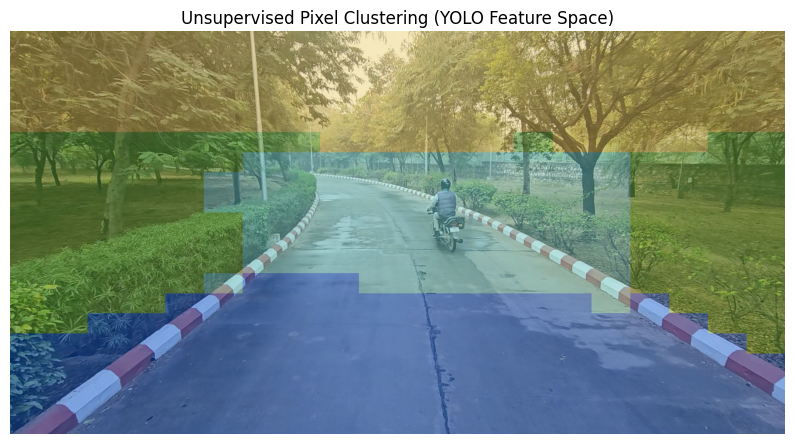

In [22]:
plt.figure(figsize=(10, 6))
plt.imshow(overlay)
plt.title("Unsupervised Pixel Clustering (YOLO Feature Space)")
plt.axis("off")